# Optimal Control via the Feasible Trajectory Affine Space

This example demonstrates convex quadratic optimal control over the **feasible
trajectory affine space** of a controlled linear system.  We use the double
integrator

$$
  \ddot{x} = u
  \qquad\Longleftrightarrow\qquad
  \dot{q}(t) = \begin{bmatrix}0 & 1\\0 & 0\end{bmatrix} q(t)
             + \begin{bmatrix}0\\1\end{bmatrix} u(t),
$$

where the state is $q = [x, \dot{x}]^\top$ (position and velocity) and the
control input is the acceleration $u$.

We fix the initial and terminal states and find the LQR-optimal state-control
trajectory via two complementary viewpoints:

1. **The feasible affine space** (from the sheaf boundary-value problem):
   $\mathcal{T}(q_1, q_{k+1}) = \{ z_p + N\alpha : \alpha \in \mathbb{R}^r \}$.
2. **The reduced quadratic program** in the free coordinate $\alpha$:
   $\min_\alpha \tfrac{1}{2} \alpha^\top (N^\top H N) \alpha + \alpha^\top N^\top (H z_p + f)$.

In [1]:
using CellularSheaves
using LinearAlgebra
using BlockArrays
using Plots

## System definition

We discretize the continuous-time double integrator with sample period `h`
using zero-order hold.

In [2]:
Ac = [0.0  1.0;
      0.0  0.0]
Bc = reshape([0.0, 1.0], 2, 1)

h = 0.25    # sample period (seconds)
k = 8       # number of time steps

8

## Build the ControlledTrajectorySheaf

A `ControlledTrajectorySheaf` wraps the zero-order-hold discretization
$q_{t+1} = A_d q_t + B_d u_t$ as a path-graph sheaf.  Its global sections
are exactly the feasible sampled state-control trajectories.

In [3]:
F  = EuclideanSheaf{Float64}(fill(2, 1))   # base sheaf: one vertex with a 2-dimensional stalk
ts = ControlledTrajectorySheaf(F, Ac, Bc, h, k)

println("State dimension n = ", ts.state_dim)
println("Control dimension m = ", ts.control_dim)
println("Steps k = ", ts.k)

Ad = ts.Ad
Bd = ts.Bd
println("Ad = ", Ad)
println("Bd = ", Bd)

State dimension n = 2
Control dimension m = 1
Steps k = 8
Ad = [1.0 0.25; 0.0 1.0]
Bd = [0.03125; 0.25;;]


## Endpoint conditions

We start at rest and aim to reach a target position with zero velocity.

In [4]:
q1  = [0.0, 0.0]   # initial state: position = 0, velocity = 0
qk1 = [1.0, 0.0]   # terminal state: position = 1, velocity = 0

2-element Vector{Float64}:
 1.0
 0.0

## Feasible trajectory affine space

`feasible_control_trajectory_basis` returns:
- `z_p` — a particular feasible trajectory (the minimum-energy / harmonic solution),
- `N`   — a basis matrix whose columns span all endpoint-preserving perturbations.

Any feasible trajectory can be written $z = z_p + N\alpha$ for some $\alpha$.

In [5]:
z_p_raw, N = feasible_control_trajectory_basis(ts, q1, qk1)

n = ts.state_dim
m = ts.control_dim
p = (k + 1) * n + k * m
r = size(N, 2)

println("Trajectory dimension p = ", p)
println("Null-space dimension r = ", r, "  (free parameters)")

Trajectory dimension p = 26
Null-space dimension r = 6  (free parameters)


## LQR objective

We minimize the quadratic running cost

$$
  J(z) = \tfrac{1}{2} \sum_{t=1}^{k}
    \bigl( q_t^\top Q\, q_t + u_t^\top R_u\, u_t \bigr)
  + \tfrac{1}{2}\, q_{k+1}^\top Q_f\, q_{k+1},
$$

with identity weights on states and controls and a large terminal weight to
encourage the terminal velocity to be small.

In [6]:
Q  = Matrix{Float64}(I, n, n)
Ru = Matrix{Float64}(I, m, m)
Qf = 10.0 * Matrix{Float64}(I, n, n)   # heavier terminal penalty

H, f, c = lqr_objective(ts, Q, Ru; Qf=Qf)

println("Size of H: ", size(H))

Size of H: (26, 26)


## Reduced quadratic program

`optimal_control_trajectory` restricts the quadratic objective to
the feasible affine space and solves the reduced problem

$$
  R_{\mathrm{red}}\, \alpha^\star = -r_{\mathrm{red}},
  \qquad
  R_{\mathrm{red}} = N^\top H N,
  \quad
  r_{\mathrm{red}} = N^\top (H z_p + f).
$$

When the reduced Hessian is singular (which does not happen here), the
minimum-norm optimizer is returned automatically.

In [7]:
z_opt, α_opt, z_p_block, null_basis =
    optimal_control_trajectory(ts, q1, qk1, H, f)

([0.0, 0.0, 0.04039956395753974, 0.3231965116603207, 0.1493067616029349, 0.5480610695028412, 0.30371009875632515, 0.6871656277242815, 0.4828139305958494, 0.7456650269919128  …  1.0, 0.0, 1.2927860466412853, 0.8994582313700832, 0.5564182328857625, 0.2339975970705258, -0.09837706484502232, -0.47280560064661903, -0.9235908715920615, -1.4878865708839495], [-0.47280560064661903, -0.09837706484502232, 0.2339975970705258, 0.5564182328857625, 0.8994582313700832, 1.2927860466412853], [0.0, 0.0, -6.614900934701731e-16, -8.371508614529322e-16, -1.1449174941446954e-15, -1.1529239101876648e-15, -1.707288157002901e-15, -1.4001620375945748e-15, -2.331468351712834e-15, -1.5788652436736627e-15  …  1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 16.000000000000078, -16.00000000000007], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; -2.0000000000000004 -3.0000000000000018 … -6.000000000000008 -7.000000000000016; 1.0000000000000004 2.0000000000000018 … 5.000000000000009 6.000000000000015])

Verify the first-order optimality condition holds.

In [8]:
q_p  = Array(z_p_block)
Rred = null_basis' * H * null_basis
rred = null_basis' * (H * q_p + f)
res  = norm(Rred * α_opt + rred)
println("Optimality residual ‖Rred*α - (-rred)‖ = ", res)

Optimality residual ‖Rred*α - (-rred)‖ = 0.0


Verify that z_opt is in the affine space.

In [9]:
affine_err = norm(Array(z_opt) - (q_p + null_basis * α_opt))
println("Affine-space error ‖z_opt - (z_p + N*α)‖ = ", affine_err)

Affine-space error ‖z_opt - (z_p + N*α)‖ = 0.0


## Plot: state trajectory and control input

The state blocks are `z_opt[Block(t)]` for `t = 1, …, k+1`; the control
blocks are `z_opt[Block(k+1+t)]` for `t = 1, …, k`.

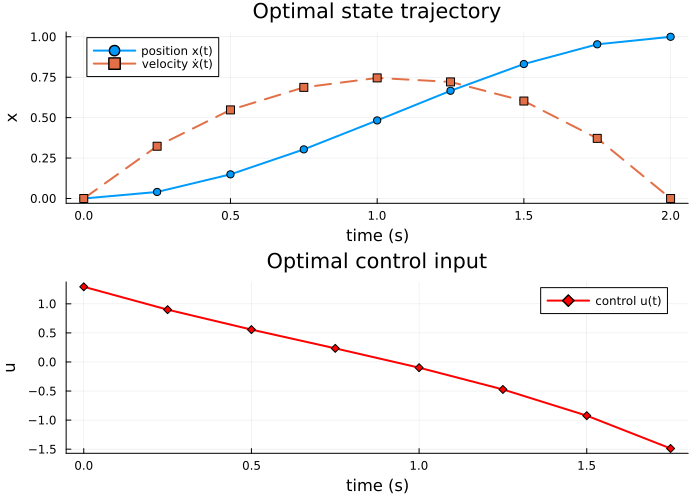

In [10]:
times_state   = h .* (0:k)
times_control = h .* (0:k-1)

positions  = [Array(z_opt[Block(t)])[1] for t in 1:k+1]
velocities = [Array(z_opt[Block(t)])[2] for t in 1:k+1]
controls   = [Array(z_opt[Block(k+1+t)])[1] for t in 1:k]

p_pos = plot(times_state, positions;
    lw=2, marker=:circle, label="position x(t)",
    xlabel="time (s)", ylabel="x",
    title="Optimal state trajectory")
plot!(p_pos, times_state, velocities;
    lw=2, marker=:square, linestyle=:dash, label="velocity ẋ(t)")

p_ctrl = plot(times_control, controls;
    lw=2, marker=:diamond, color=:red, label="control u(t)",
    xlabel="time (s)", ylabel="u",
    title="Optimal control input")

state_control_plot = plot(p_pos, p_ctrl; layout=(2, 1), size=(700, 500))

state_control_plot

## Verify endpoint conditions and discrete dynamics

Both endpoints must be satisfied exactly, and the trajectory must obey the
discrete dynamics $q_{t+1} = A_d q_t + B_d u_t$ at every step.

In [11]:
@assert Array(z_opt[Block(1)])     ≈ q1  "Initial state not satisfied"
@assert Array(z_opt[Block(k + 1)]) ≈ qk1 "Terminal state not satisfied"

for t in 1:k
    qt  = Array(z_opt[Block(t)])
    qt1 = Array(z_opt[Block(t + 1)])
    ut  = Array(z_opt[Block(k + 1 + t)])
    @assert norm(Ad * qt + Bd * ut - qt1) < 1e-10 "Dynamics violated at step $t"
end
println("All endpoint and dynamics constraints satisfied.")

All endpoint and dynamics constraints satisfied.


## Relationship to the sheaf boundary-value problem

The particular solution `z_p` is the **harmonic extension** of the boundary
data $(q_1, q_{k+1})$ to the full trajectory space.  It minimises the
sheaf Laplacian energy (i.e., the squared coboundary $\|d z\|^2$).

The null-basis columns $N_j$ are the *global sections of the controlled
sheaf* (after zeroing the two boundary vertices), which are exactly the
endpoint-preserving degrees of freedom.

The optimal trajectory lives in the affine space `z_p + N α*`, where `α*` is
chosen to minimise the LQR cost restricted to that affine space.  The two
viewpoints — sheaf/harmonic-extension and quadratic/LQR — combine cleanly
because the feasible set is a finite-dimensional affine subspace.